In [1]:
from pathlib import Path
import numpy as np
import random
import tensorflow as tf
import librosa

from tensorflow.keras.applications import ResNet50

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

data_path = Path(r"C:\Users\princ\OneDrive - University of Strathclyde\Documents\university\fourth year\diss\AT4")

print(tf.__version__)
print(data_path.exists())

2.12.0
True


In [5]:
folders = [f for f in data_path.iterdir() if f.is_dir()]

for f in folders:
    files = list(f.rglob("*.wav"))
    print(f.name, len(files))

Healthy 1190
Pathology 1820


In [6]:
healthy_files = list((data_path / "Healthy").rglob("*.wav"))
path_files = list((data_path / "Pathology").rglob("*.wav"))

random.shuffle(healthy_files)
random.shuffle(path_files)

n = min(len(healthy_files), len(path_files))

healthy_files = healthy_files[:n]
path_files = path_files[:n]

files = healthy_files + path_files
labels = [0]*n + [1]*n

print(len(files), len(labels))

2380 2380


In [7]:
file = files[0]
y, sr = librosa.load(file, sr=22050)

spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
spec = librosa.power_to_db(spec, ref=np.max)

print(spec.shape)

(128, 49)


In [8]:
from tensorflow.image import resize

img = resize(spec[..., np.newaxis], [224, 224]).numpy()
img = np.repeat(img, 3, axis=-1)

print(img.shape)

(224, 224, 3)


In [9]:
X = []
y = []

for file, label in zip(files, labels):
    audio, sr = librosa.load(file, sr=22050)
    spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    spec = librosa.power_to_db(spec, ref=np.max)
    img = tf.image.resize(spec[..., np.newaxis], [224, 224]).numpy()
    img = np.repeat(img, 3, axis=-1)
    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2380, 224, 224, 3)
(2380,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1904, 224, 224, 3)
(476, 224, 224, 3)
(1904,)
(476,)


In [11]:
from tensorflow.keras.applications.resnet import preprocess_input

X_train = preprocess_input(X_train)
X_test = preprocess_input(X_test)

In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early, reduce_lr]
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5399 - loss: 0.7387 - val_accuracy: 0.6387 - val_loss: 0.6297 - learning_rate: 1.0000e-04
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6166 - loss: 0.6580 - val_accuracy: 0.6660 - val_loss: 0.6091 - learning_rate: 1.0000e-04
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6434 - loss: 0.6249 - val_accuracy: 0.6849 - val_loss: 0.5911 - learning_rate: 1.0000e-04
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6612 - loss: 0.6043 - val_accuracy: 0.6870 - val_loss: 0.5823 - learning_rate: 1.0000e-04
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6581 - loss: 0.5924 - val_accuracy: 0.6954 - val_loss: 0.5766 - learning_rate: 1.0000e-04
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6843 - loss: 0.5830 - val_accuracy: 0.7017 - val_loss: 0.5728 - learning_rate: 1.0000e-04
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7159 - loss:

In [14]:
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early, reduce_lr]
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6812 - loss: 0.6388 - val_accuracy: 0.7122 - val_loss: 0.5600 - learning_rate: 1.0000e-05
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8592 - loss: 0.3437 - val_accuracy: 0.6807 - val_loss: 0.6084 - learning_rate: 1.0000e-05
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9349 - loss: 0.2297 - val_accuracy: 0.7227 - val_loss: 0.5659 - learning_rate: 5.0000e-06
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9590 - loss: 0.1796 - val_accuracy: 0.7521 - val_loss: 0.5305 - learning_rate: 5.0000e-06


15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 991ms/step
Threshold: 0.40 Accuracy: 73.95%
Threshold: 0.50 Accuracy: 71.22%
Threshold: 0.60 Accuracy: 65.13%
Best threshold: 0.40
Best accuracy: 73.95%


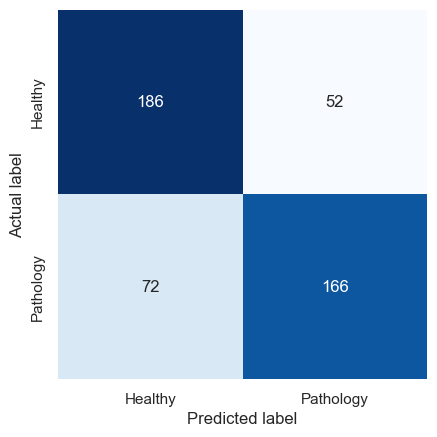

              precision    recall  f1-score   support

     Healthy       0.72      0.78      0.75       238
   Pathology       0.76      0.70      0.73       238

    accuracy                           0.74       476
   macro avg       0.74      0.74      0.74       476
weighted avg       0.74      0.74      0.74       476



In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

y_prob = model.predict(X_test).ravel()

best_t = 0.5
best_acc = 0

for t in [0.4, 0.5, 0.6]:
    y_pred = (y_prob > t).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"Threshold: {t:.2f} Accuracy: {acc * 100:.2f}%")
    if acc > best_acc:
        best_acc = acc
        best_t = t

print(f"Best threshold: {best_t:.2f}")
print(f"Best accuracy: {best_acc * 100:.2f}%")

y_pred = (y_prob > best_t).astype(int)

mat = confusion_matrix(y_test, y_pred)

class_labels = ["Healthy", "Pathology"]

sns.heatmap(mat, square=True, annot=True, fmt="d", cbar=False, cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.savefig("heatmap.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred, target_names=class_labels))

In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("Accuracy at 0.5 threshold:", acc)

y_pred_04 = (model.predict(X_test) > 0.4).astype(int)
acc_04 = accuracy_score(y_test, y_pred_04)
print("Accuracy at 0.4 threshold:", acc_04)

y_pred_06 = (model.predict(X_test) > 0.6).astype(int)
acc_06 = accuracy_score(y_test, y_pred_06)
print("Accuracy at 0.6 threshold:", acc_06)

15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 947ms/step
Accuracy at 0.5 threshold: 0.7121848739495799
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 939ms/step
Accuracy at 0.4 threshold: 0.7394957983193278
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
Accuracy at 0.6 threshold: 0.6512605042016807


In [17]:
model.save("ResNet.keras")